# **1. Project Context**

### **1.1 Problem**
Educational institutions need to identify students who may experience poor academic outcomes early enough to provide appropriate academic support. This project investigates whether machine learning can predict a student's final academic performance using available student-related information.*italicized text*

### **1.2 Prediction Task**

**primary task:**

Predict the student's final grade (G3) using supervised regression.

**secondary use of the prediction is:**

Students with predicted G3 below a predefined threshold can be flagged as potentially requiring academic review/support.

### **1.3 Target**

* **Target variable**: G3
* **Type**: Numerical / continuous
* **Range**: 0-20
* **Meaning**: Final grade

# **2. Dataset Overview**

### **2.1 Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Ml_Assignment/Data/student-mat.csv", sep=";")

In [3]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


### **2.2 Dataset source**

* **Source**: UCI Machine Learning Repository
* **Dataset**: Mathematics (student-mat.csv)
* **Domain**: Education
* **Target**: G3 — final grade

**Dataset DOI** : [Dataset](https://archive.ics.uci.edu/dataset/320/student+performance)


### **2.3 Shape**

In [4]:
df.shape

(395, 33)

### **2.4 Row meaning**

In [5]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Each row represents an individual secondary-school student. The columns contain demographic, family, social, school related, and academic characteristics associated with that student.

### **2.5 Unit of analysis**

**Unit of analysis**: Individual student

Therefore, each prediction produced by the model will correspond to one individual student.

# **3. Data Dictionary**

# Data Dictionary — Student Performance Dataset

| # | Variable | Description | Statistical Type | Role | Value Range (full description) |
|---|----------|-------------|-------------------|------|----------------------------------|
| 1 | school | Student's school | Nominal categorical | Feature | Gabriel Pereira, or Mousinho da Silveira |
| 2 | sex | Student's sex | Nominal categorical| Feature | Female, or Male |
| 3 | age | Student's age | Discrete numeric| Feature | Fifteen to twenty-two years |
| 4 | address | Home address type | Nominal categorical | Feature | Urban, or Rural |
| 5 | famsize | Family size | Nominal categorical | Feature | Less than or equal to three family members, or greater than three family members |
| 6 | Pstatus | Parent's cohabitation status | Nominal categorical| Feature | Living together, or living apart |
| 7 | Medu | Mother's education | Ordinal categorical | Feature | None, primary education, fifth to ninth grade, secondary education, or higher education |
| 8 | Fedu | Father's education | Ordinal categorical | Feature | None, primary education, fifth to ninth grade, secondary education, or higher education |
| 9 | Mjob | Mother's job | Nominal categorical | Feature | Teacher, health care related, civil services , stay-at-home, or other |
| 10 | Fjob | Father's job | Nominal categorical | Feature | Teacher, health care related, civil services , stay-at-home, or other |
| 11 | reason | Reason for choosing school | Nominal categorical | Feature | Close to home, school reputation, course preference, or other |
| 12 | guardian | Student's guardian | Nominal categorical | Feature | Mother, father, or other |
| 13 | traveltime | Home-to-school travel time | Ordinal categorical  | Feature | Less than fifteen minutes, fifteen to thirty minutes, thirty minutes to one hour, or more than one hour |
| 14 | studytime | Weekly study time | Ordinal categorical | Feature | Less than two hours, two to five hours, five to ten hours, or more than ten hours |
| 15 | failures | Number of past class failures | Discrete numeric | Feature | Zero, one, or two failures recorded individually; three or more failures grouped together as one bucket |
| 16 | schoolsup | Extra educational support | Nominal categorical | Feature | Yes, or no |
| 17 | famsup | Family educational support | Nominal categorical | Feature | Yes, or no |
| 18 | paid | Extra paid classes | Nominal categorical| Feature | Yes, or no |
| 19 | activities | Extra-curricular activities | Nominal categorical | Feature | Yes, or no |
| 20 | nursery | Attended nursery school | Nominal categorical | Feature | Yes, or no |
| 21 | higher | Wants higher education | Nominal categorical | Feature | Yes, or no |
| 22 | internet | Internet access at home | Nominal categorical | Feature | Yes, or no |
| 23 | romantic | In a romantic relationship | Nominal categorical| Feature | Yes, or no |
| 24 | famrel | Quality of family relationships | Ordinal categorical | Feature | Very bad, bad, average, good, or excellent |
| 25 | freetime | Free time after school | Ordinal categorical | Feature | Very low, low, average, high, or very high |
| 26 | goout | Going out with friends | Ordinal categorical | Feature | Very low, low, average, high, or very high |
| 27 | Dalc | Workday alcohol consumption | Ordinal categorical | Feature | Very low, low, average, high, or very high |
| 28 | Walc | Weekend alcohol consumption | Ordinal categorical | Feature | Very low, low, average, high, or very high |
| 29 | health | Current health status | Ordinal categorical | Feature | Very bad, bad, average, good, or very good |
| 30 | absences | Number of school absences | Discrete numeric | Feature | Zero to ninety-three absences |
| 31 | G1 | First period grade | Discrete numeric  | Feature | Zero to twenty points |
| 32 | G2 | Second period grade | Discrete numeric  | Feature| Zero to twenty points |
| 33 | G3 | Final grade | Discrete numeric| Target | Zero to twenty points |

# **4. Initial Data Inspection**

In [6]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [9]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


Value counts For categorical variables:

In [10]:
df["school"].value_counts()

,count
school,
GP,349
MS,46


In [11]:
df["sex"].value_counts()

,count
sex,
F,208
M,187


In [12]:
df["Mjob"].value_counts()

,count
Mjob,
other,141
services,103
at_home,59
teacher,58
health,34


Value counts For ordinal variables:

In [13]:
df["studytime"].value_counts().sort_index()

,count
studytime,
1,105
2,198
3,65
4,27


In [14]:
df["failures"].value_counts().sort_index()

,count
failures,
0,312
1,50
2,17
3,16


# **5. Target Analysis**

### **5.1 Basic statistics**

In [15]:
df["G3"].describe()

,G3
count,395.000000
mean,10.415190
std,4.581443
min,0.000000
25%,8.000000
50%,11.000000
75%,14.000000
max,20.000000


In [16]:
df["G3"].value_counts().sort_index()

,count
G3,
0,38
4,1
5,7
6,15
7,9
8,32
9,28
10,56
11,47


### **5.2 Distribution**

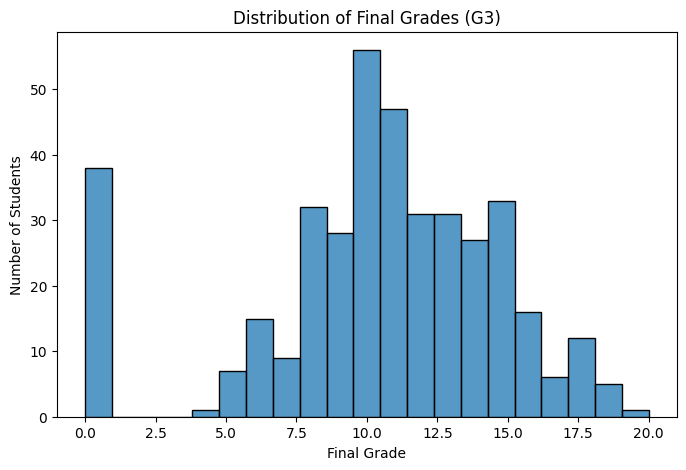

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="G3", bins=21)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

* Grades typically cluster in a bell-ish shape somewhere in the
8 -14 range.But the spike of zeros creates a second small cluster at the bottom, making the overall distribution bimodal.

* Grades concentrated around 10-12.

* The 38 zeros are the standout anomaly. They're can be missing-data-in-disguise rather than true low performance.

### **5.3 Boxplot**

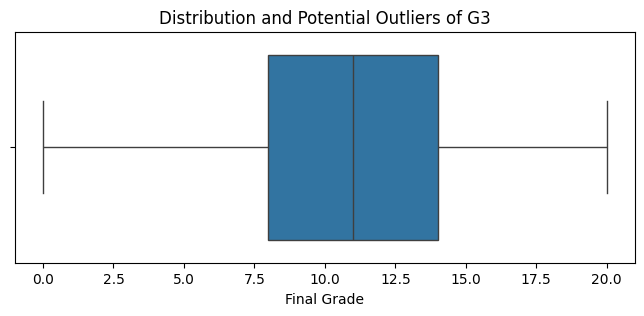

In [18]:
plt.figure(figsize=(8, 3))

sns.boxplot(x=df["G3"])

plt.title("Distribution and Potential Outliers of G3")
plt.xlabel("Final Grade")

plt.show()

# **6. Exploratory Data Analysis**

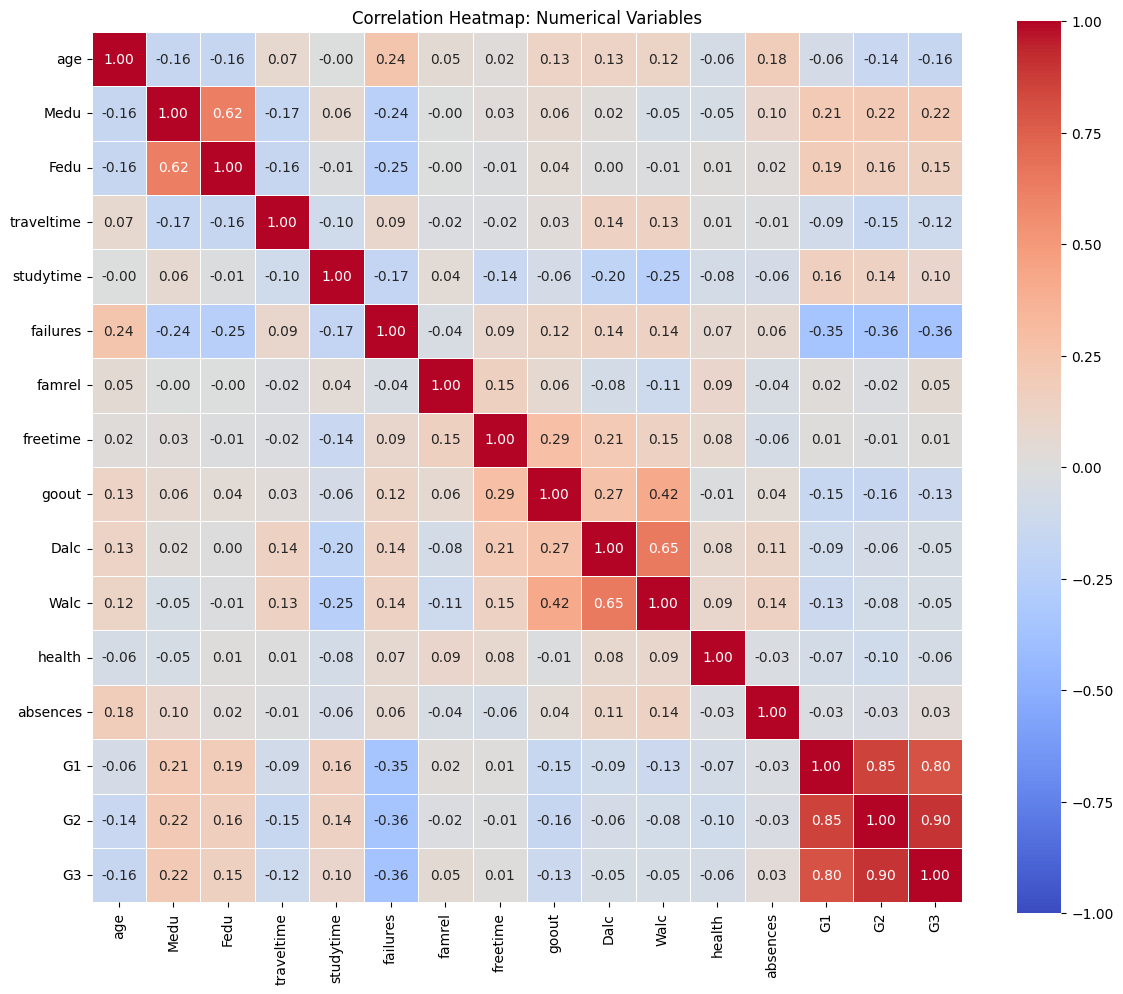

In [19]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    fmt=".2f",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap: Numerical Variables")
plt.tight_layout()
plt.show()

## Heatmap Interpretation:

**Correlation with G3 (Target)**

| Variable | r | Note |
|---|---|---|
| G2 | 0.90 | Strongest predictor |
| G1 | 0.80 | Very strong |
| failures | -0.36 | Strongest non-grade predictor |
| Medu | 0.22 | Weak-moderate |
| age | -0.16 | Likely proxy for failures, not direct effect |
| Fedu | 0.15 | Weak |
| goout | -0.13 | Weak |
| traveltime | -0.12 | Weak |
| studytime | 0.10 | Weaker than expected |
| famrel, freetime, health, absences, Dalc, Walc | ~0.00–0.06 | Negligible |

**Multicollinearity Among Predictors**

| Pair | r | Note |
|---|---|---|
| G1 ↔ G2 | 0.85 | Expected (G2 builds on G1) |
| Dalc ↔ Walc | 0.65 | Redundant if both used |
| Medu ↔ Fedu | 0.62 | Redundant if both used |
| goout ↔ Walc | 0.42 | Social/drinking overlap |
| failures ↔ age | 0.24 | Explains age's weak G3 link |

**Key Takeaways**
- G1/G2 dominate G3 prediction — excluding them is the harder, more meaningful modeling task.
- `failures` is the strongest standalone demographic/behavioral predictor.
- Most demographic/social/lifestyle variables are weak individually
- Multicollinearity present (Dalc/Walc, Medu/Fedu) — consider dropping/combining before regression.
- `age`'s effect is likely indirect, via its link to `failures`.

### **6.1 Academic variables**

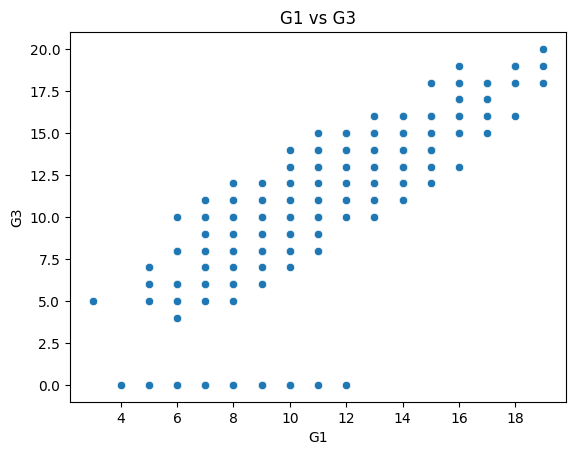

In [20]:
sns.scatterplot(data=df, x="G1", y="G3")

plt.title("G1 vs G3")
plt.show()

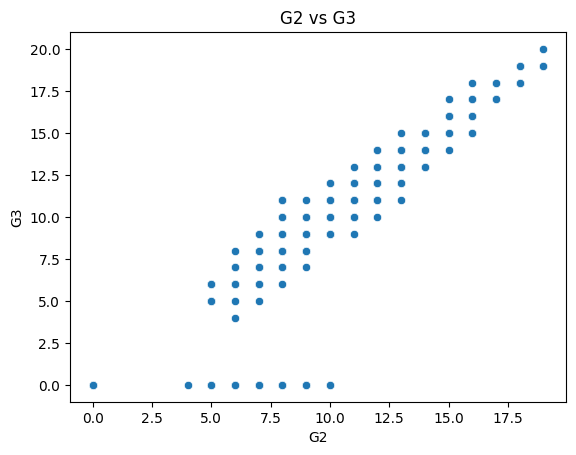

In [21]:
sns.scatterplot(data=df, x="G2", y="G3")

plt.title("G2 vs G3")
plt.show()

In [22]:
corr= df[["G1", "G2", "G3"]].corr()

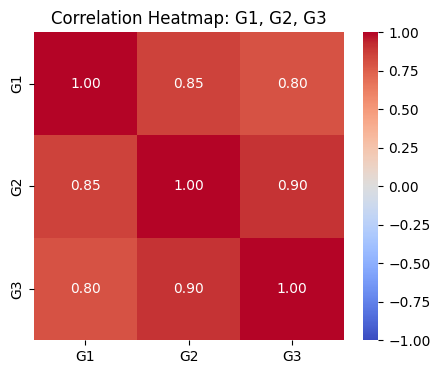

In [23]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap: G1, G2, G3")
plt.show()

### **6.2 Failures**

In [24]:
df.groupby("failures")["G3"].agg(["count", "mean", "median"])

,count,mean,median
failures,,,
0,312,11.253205,11.0
1,50,8.120000,9.0
2,17,6.235294,8.0
3,16,5.687500,7.0


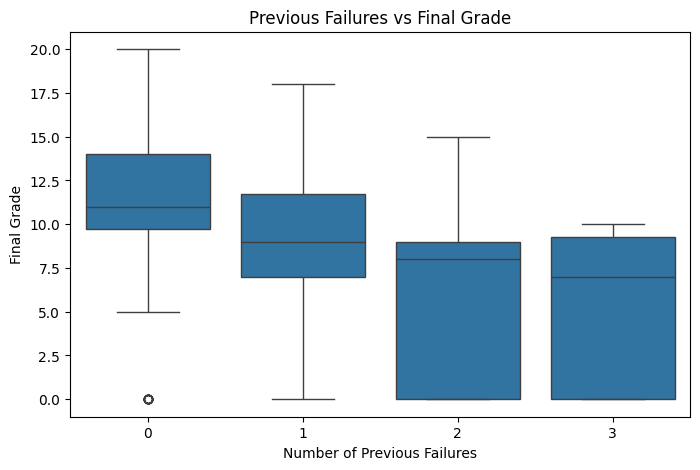

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="failures", y="G3")

plt.title("Previous Failures vs Final Grade")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Final Grade")

plt.show()

### **6.3 Studytime**

In [26]:
df.groupby("studytime")["G3"].agg(["count", "mean", "median"])

,count,mean,median
studytime,,,
1,105,10.047619,10.0
2,198,10.171717,11.0
3,65,11.400000,12.0
4,27,11.259259,12.0


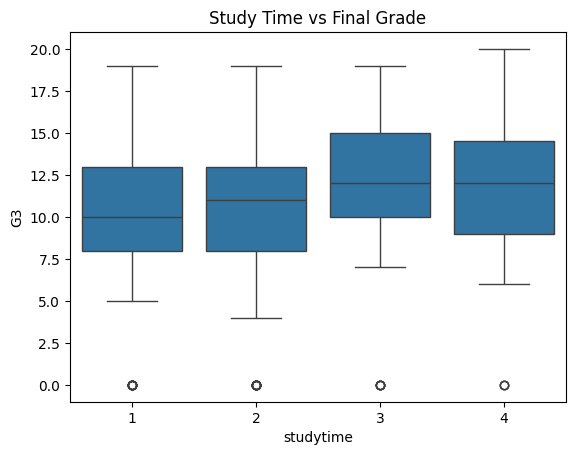

In [27]:
sns.boxplot(data=df, x="studytime", y="G3")

plt.title("Study Time vs Final Grade")
plt.show()

### **6.4 Attendance**

In [28]:
df["absences"].describe()

,absences
count,395.000000
mean,5.708861
std,8.003096
min,0.000000
25%,0.000000
50%,4.000000
75%,8.000000
max,75.000000


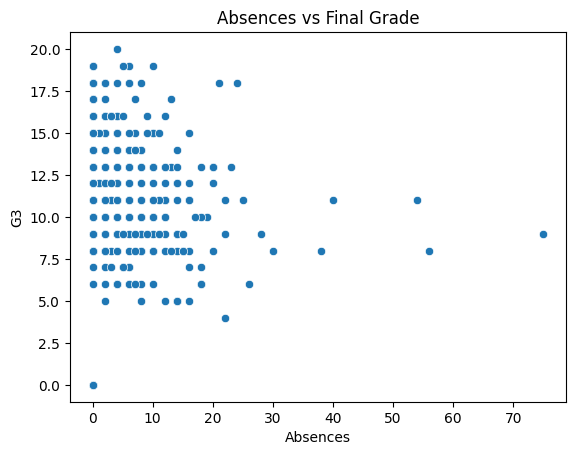

In [29]:
sns.scatterplot(data=df, x="absences", y="G3")

plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("G3")

plt.show()

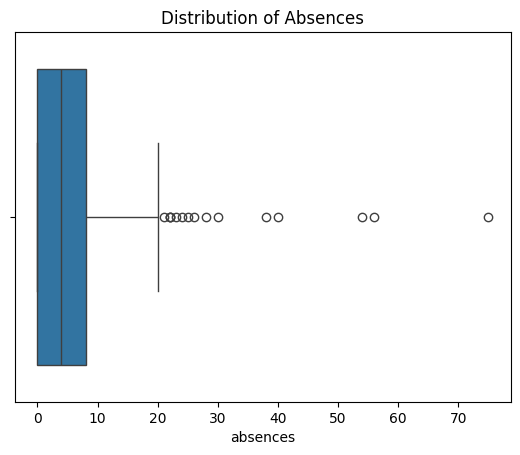

In [30]:
sns.boxplot(x=df["absences"])

plt.title("Distribution of Absences")
plt.show()

### **6.5 Demographic/social variables**

     count       mean  median
sex                          
F      208   9.966346    10.0
M      187  10.914439    11.0


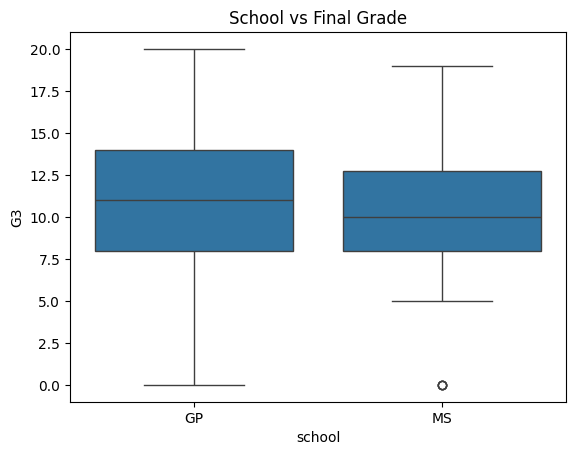

      count       mean  median
Medu                          
0         3  13.000000    15.0
1        59   8.677966    10.0
2       103   9.728155    11.0
3        99  10.303030    10.0
4       131  11.763359    12.0


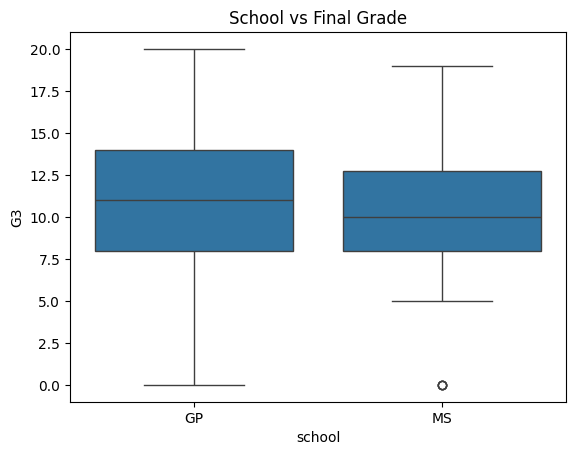

      count       mean  median
Fedu                          
0         2  13.000000    13.0
1        82   9.158537    10.0
2       115  10.260870    11.0
3       100  10.660000    10.0
4        96  11.364583    12.0


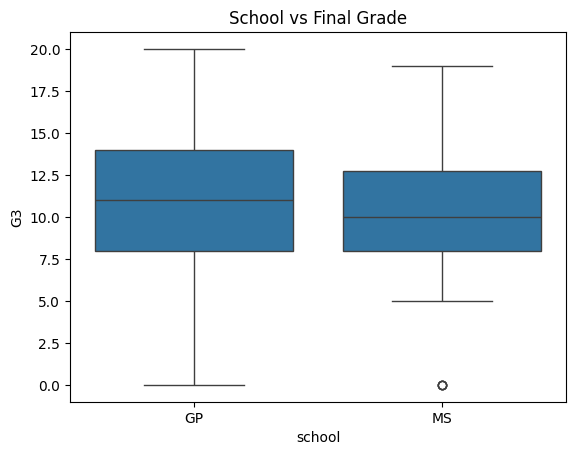

          count       mean  median
Mjob                              
at_home      59   9.152542    10.0
health       34  12.147059    13.0
other       141   9.822695    11.0
services    103  11.019417    11.0
teacher      58  11.051724    11.0


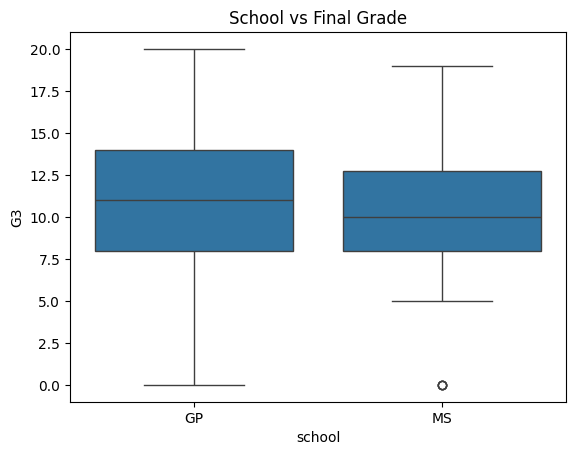

          count       mean  median
Fjob                              
at_home      20  10.150000    11.0
health       18  11.611111    11.0
other       217  10.193548    11.0
services    111  10.297297    11.0
teacher      29  11.965517    14.0


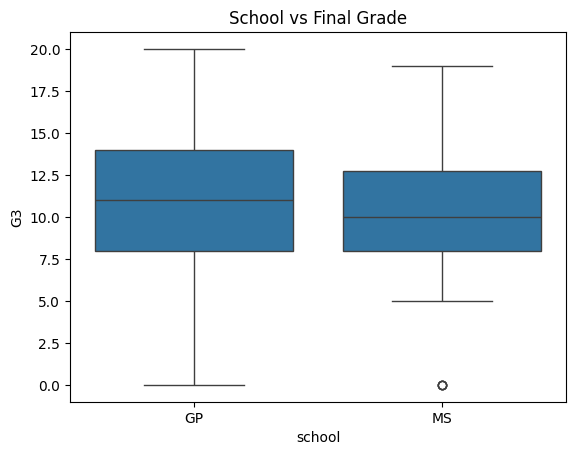

        count    mean  median
higher                       
no         20   6.800     8.0
yes       375  10.608    11.0


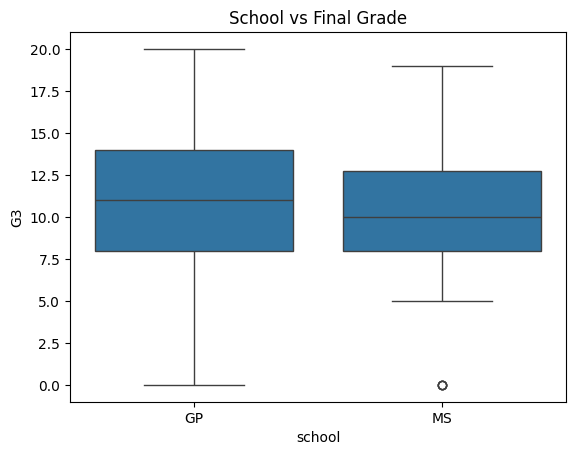

          count       mean  median
internet                          
no           66   9.409091    10.0
yes         329  10.617021    11.0


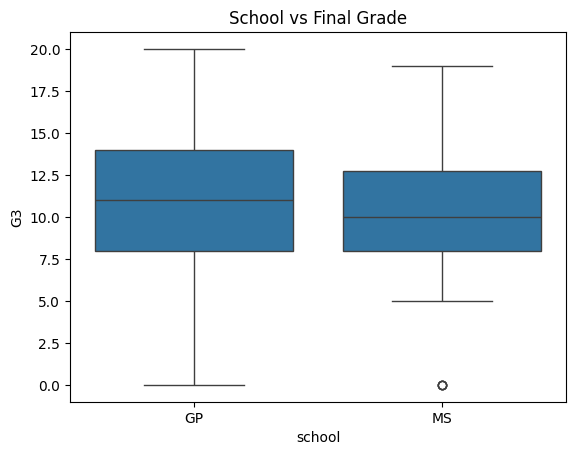

          count       mean  median
romantic                          
no          263  10.836502    11.0
yes         132   9.575758    11.0


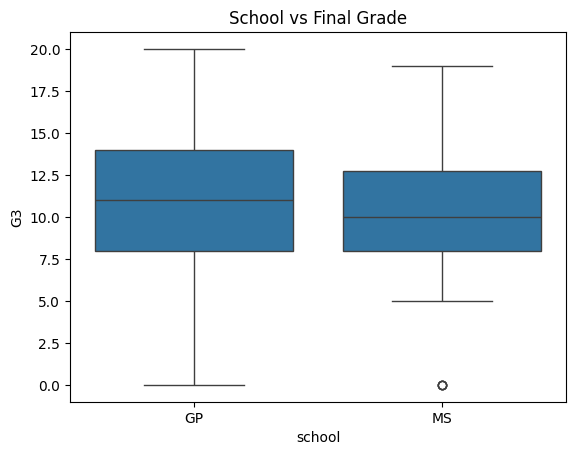

In [31]:
demo_vars = [
    "sex","Medu", "Fedu", "Mjob", "Fjob",
   "higher", "internet", "romantic"
]

for v in demo_vars:
  print(df.groupby(v)["G3"].agg(["count", "mean", "median"]))
  sns.boxplot(data=df, x="school", y="G3")

  plt.title("School vs Final Grade")
  plt.show()


# **7. Data Quality Analysis**

### **7.1 Missing values**

In [32]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [33]:
df.isnull().sum().sum()

np.int64(0)

### **7.2 Duplicates**

In [34]:
df.duplicated().sum()

np.int64(0)

### **7.3 Outliers**

In [35]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


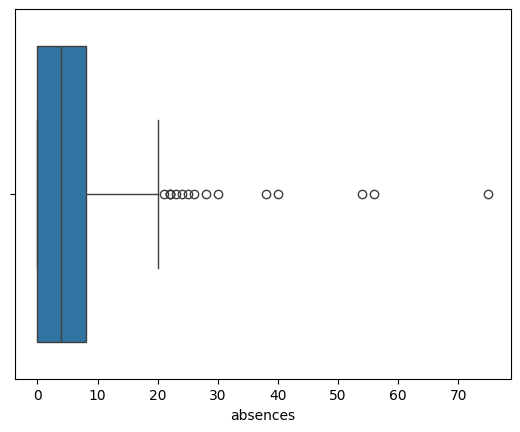

In [36]:
sns.boxplot(x=df["absences"])
plt.show()

### **7.4** Data consistency

In [37]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


school
['GP' 'MS']

sex
['F' 'M']

address
['U' 'R']

famsize
['GT3' 'LE3']

Pstatus
['A' 'T']

Mjob
['at_home' 'health' 'other' 'services' 'teacher']

Fjob
['teacher' 'other' 'services' 'health' 'at_home']

reason
['course' 'other' 'home' 'reputation']

guardian
['mother' 'father' 'other']

schoolsup
['yes' 'no']

famsup
['no' 'yes']

paid
['no' 'yes']

activities
['no' 'yes']

nursery
['yes' 'no']

higher
['yes' 'no']

internet
['no' 'yes']

romantic
['no' 'yes']


# **8. Key EDA Insights**

| ID | Observation | Evidence | Why it matters | Action |
|----|---|---|---|---|
| 1 | G3 is bimodal with a spike at zero | 38/395 (~9.6%) have G3=0; rest cluster 8–14 (mean 10.42) | Zeros likely = dropouts, not true low grades | investigate zero-G3 rows before modeling |
| 2 | G1, G2 strongly correlate with G3 | Corr: G1–G3=0.80, G2–G3=0.90, G1–G2=0.85 | G2 near-proxies G3; risk of leakage | Build separate models with/without G1–G2 |
| 3 | Past failures strongly lower G3 | Mean G3 by failures: 0→11.25, 1→8.12, 2→6.24, 3→5.69 | Strongest non-grade predictor | Keep `failures` as key feature |
| 4 | Studytime helps but plateaus | Mean G3: 1→10.05, 2→10.17, 3→11.40, 4→11.26 | Relationship isn't linear | Treat `studytime` as ordinal, not linear |
| 5 | Absences are skewed with outliers | Mean 5.71, median 4, max 75; outlier cutoff ≈20 | Outliers can dominate model error | Cap/log-transform `absences` |
| 6 | No missing or duplicate data | 0 nulls, 0 duplicate rows | Low cleaning burden | Skip imputation/dedup, go to encoding |
| 7 | Some categories are imbalanced | school GP=349 vs MS=46; higher yes=375 vs no=20 | Sparse minority classes hurt encoding | Group rare categories; use regularization |
| 8 | "Wants higher ed" shows big G3 gap | Mean G3: yes=10.61 (n=375), no=6.80 (n=20) | Large effect, but small "no" sample | Keep feature, note low confidence |
| 9 | Categorical values are clean | `unique()` shows only expected labels, no typos | No re-coding needed | Proceed to standard encoding |

# **10. Data Understanding Conclusions**

1. Data quality is high. The dataset has no missing values, no duplicate rows, and clean, consistent categorical labels

2. The target (G3) needs a decision before modeling. Its distribution is bimodal because of 38 students scoring exactly 0, which most plausibly reflects withdrawal/absence from the final assessment rather than true academic failure.

3. G1 and G2 dominate the signal. With correlations of 0.80-0.90 to G3, the periodic grades are by far the strongest predictors  strong enough to raise a leakage question depending on the use case.

4. Several categorical variables are imbalanced, meaning some subgroup effects (school type, mother's job, wanting higher education) are estimated from very few observations and should be treated cautiously


Overall: the dataset is well-suited to the stated regression task